# ResNet18 Fine-Tuning auf FER-2013

Standalone Training: Lädt Daten, balanciert Klassen, trainiert ResNet18,
zeigt Ergebnisse als Plots und speichert das Modell.

In [12]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import numpy as np
import os, random

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [16]:
EPOCHS = 20
BATCH_SIZE = 32
LR = 0.001
NUM_CLASSES = 7

EMOTIONEN = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

## 1. Data Augmentation

Training bekommt zufällige Spiegelungen, Drehungen und Helligkeits-
Variationen. Das Test-Set bleibt unverändert.

In [17]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),

    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), value='random')
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

## 2. Dataset + WeightedRandomSampler

Der Sampler gleicht die ungleiche Verteilung der Emotionen aus,
indem seltene Klassen häufiger gezogen werden.

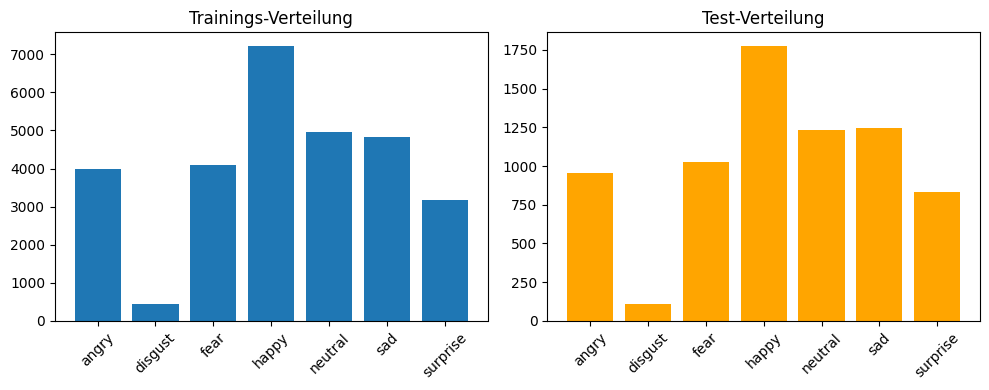

Trainings-Batches: 898, Test-Batches: 225


In [18]:
train_dataset = datasets.ImageFolder(root="../data/raw/train", transform=train_transform)
test_dataset  = datasets.ImageFolder(root="../data/raw/test",  transform=test_transform)

# Class Distribution anzeigen
train_counts = [len(os.listdir(f"../data/raw/train/{c}")) for c in EMOTIONEN]
test_counts  = [len(os.listdir(f"../data/raw/test/{c}"))  for c in EMOTIONEN]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(EMOTIONEN, train_counts)
plt.title("Trainings-Verteilung")
plt.xticks(rotation=45)
plt.subplot(1, 2, 2)
plt.bar(EMOTIONEN, test_counts, color="orange")
plt.title("Test-Verteilung")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gewichte pro Klasse: 1 / Anzahl (seltene = höheres Gewicht)
class_weights = 1.0 / torch.tensor(train_counts, dtype=torch.float)
sample_weights = class_weights[train_dataset.targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=4)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=8, pin_memory=True)

print(f"Trainings-Batches: {len(train_loader)}, Test-Batches: {len(test_loader)}")

## 3. Modell laden

ResNet18 mit ImageNet-Vorwissen. Nur den letzten FC-Layer ersetzen.

In [19]:
model = models.resnet18(weights="DEFAULT")
model.fc = nn.Linear(512, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print(f"Modell auf: {next(model.parameters()).device}")
print(f"Parameter: {sum(p.numel() for p in model.parameters()):,}")

Modell auf: cuda:0
Parameter: 11,180,103


## 4. Training

Pro Epoche: Trainieren → Loss speichern → Validieren → Accuracy speichern

In [ ]:
import torch
import os
from datetime import datetime

train_losses = []
val_losses = []
test_accs = []

# Tracker für den besten Checkpoint (wir gehen nach dem niedrigsten Val Loss)
best_val_loss = float('inf')
checkpoint_path = "best_model_checkpoint.pth"

for epoch in range(1, EPOCHS + 1):
    # ==================== TRAINING ====================
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ==================== EVALUATION ====================
    model.eval()
    running_val_loss = 0.0  # Tracker zurücksetzen
    correct = 0
    total = 0
    
    # Listen für die Per-Class Accuracy (7 Emotionen)
    class_correct = [0] * 7
    class_total = [0] * 7
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            
            # 1. Validation Loss berechnen & JETZT KORREKT KUMULIEREN (+=)
            val_loss = criterion(logits, labels)
            running_val_loss += val_loss.item()
            
            # Gesamt-Accuracy bestimmen
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            # 2. Per-Class Statistik sammeln
            c = (preds == labels).squeeze()
            if c.dim() == 0:  # Falls Batch-Größe unglücklicherweise mal 1 ist
                c = c.unsqueeze(0)
            for i in range(len(labels)):
                label = labels[i].item()
                class_correct[label] += c[i].item()
                class_total[label] += 1

    # Durchschnittlichen Validation Loss berechnen
    avg_val_loss = running_val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    accuracy = correct / total * 100
    test_accs.append(accuracy)

    # ==================== CHECKPOINT SAVING ====================
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        # Speichert den absolut besten Zustand der Gewichte
        torch.save(model.state_dict(), checkpoint_path)
        checkpoint_msg = f"Neuer bester Val Loss! Modell gespeichert unter '{checkpoint_path}'"
    else:
        checkpoint_msg = f"Kein Fortschritt beim Val Loss (Bester: {best_val_loss:.4f})"

    # Scheduler anpassen & aktuelle LR holen
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]
    
    # Hauptübersicht der Epoche im Terminal ausgeben
    print(f"\n=================== EPOCHE {epoch:2d}/{EPOCHS} ===================")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Gesamt-Acc: {accuracy:.2f}% | LR: {current_lr:.0e}")
    print(checkpoint_msg)
    
    # 3. Per-Class Accuracy direkt anzeigen
    print("\n📊 Accuracy pro Emotion:")
    for i in range(7):
        if class_total[i] > 0:
            class_acc = 100 * class_correct[i] / class_total[i]
            print(f"   {EMOTIONEN[i]:<10}: {class_acc:.2f}% ({class_correct[i]}/{class_total[i]})")
        else:
            print(f"   {EMOTIONEN[i]:<10}: Keine Testdaten")
    print("===================================================\n")

Epoche  1/20 | Loss: 1.4024 | Accuracy: 51.21% | LR: 1e-03
Epoche  2/20 | Loss: 1.1756 | Accuracy: 57.34% | LR: 1e-03
Epoche  3/20 | Loss: 1.0717 | Accuracy: 57.87% | LR: 1e-03
Epoche  4/20 | Loss: 1.0102 | Accuracy: 57.87% | LR: 1e-03
Epoche  5/20 | Loss: 0.9593 | Accuracy: 59.45% | LR: 5e-04
Epoche  6/20 | Loss: 0.8443 | Accuracy: 65.34% | LR: 5e-04
Epoche  7/20 | Loss: 0.8074 | Accuracy: 65.05% | LR: 5e-04
Epoche  8/20 | Loss: 0.7805 | Accuracy: 65.99% | LR: 5e-04
Epoche  9/20 | Loss: 0.7533 | Accuracy: 64.84% | LR: 5e-04
Epoche 10/20 | Loss: 0.7266 | Accuracy: 66.87% | LR: 3e-04
Epoche 11/20 | Loss: 0.6619 | Accuracy: 67.94% | LR: 3e-04
Epoche 12/20 | Loss: 0.6380 | Accuracy: 68.33% | LR: 3e-04
Epoche 13/20 | Loss: 0.6144 | Accuracy: 68.35% | LR: 3e-04
Epoche 14/20 | Loss: 0.5993 | Accuracy: 67.96% | LR: 3e-04
Epoche 15/20 | Loss: 0.5828 | Accuracy: 68.97% | LR: 1e-04
Epoche 16/20 | Loss: 0.5323 | Accuracy: 69.16% | LR: 1e-04
Epoche 17/20 | Loss: 0.5138 | Accuracy: 69.32% | LR: 1e-

## 5. Verlauf anzeigen

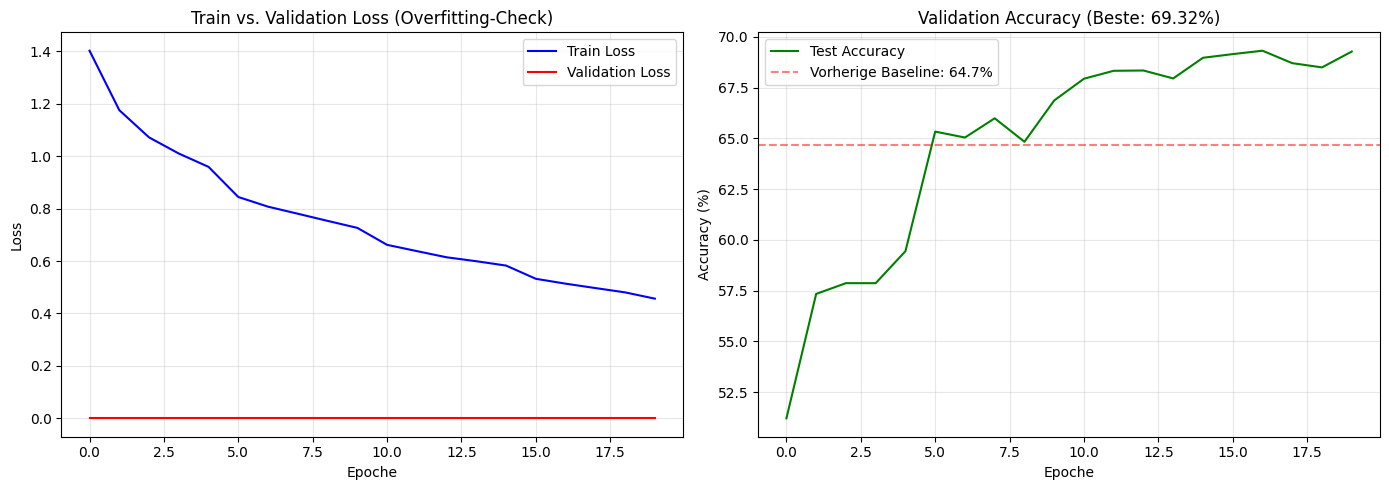

In [27]:
import matplotlib.pyplot as plt

# 1. Plot erstellen
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linker Plot: Die echten Losses übereinandergelegt
ax1.plot(train_losses, label="Train Loss", color="blue")
ax1.plot(val_losses, label="Validation Loss", color="red")
ax1.set_xlabel("Epoche")
ax1.set_ylabel("Loss")
ax1.set_title("Train vs. Validation Loss (Overfitting-Check)")
ax1.grid(True, alpha=0.3)
ax1.legend()

# Rechter Plot: Die Accuracy-Entwicklung
ax2.plot(test_accs, label="Test Accuracy", color="green")
ax2.axhline(y=64.67, color="red", linestyle="--", alpha=0.5, label="Vorherige Baseline: 64.7%")
ax2.set_xlabel("Epoche")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title(f"Validation Accuracy (Beste: {max(test_accs):.2f}%)")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Modell speichern

In [25]:
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "models/resnet_fer2013.pth")
print("Gespeichert unter models/resnet_fer2013.pth")

Gespeichert unter models/resnet_fer2013.pth


## 7. Beispiel-Vorhersagen

Zeigt einen Batch Test-Bilder mit Prediction vs. Ground Truth.

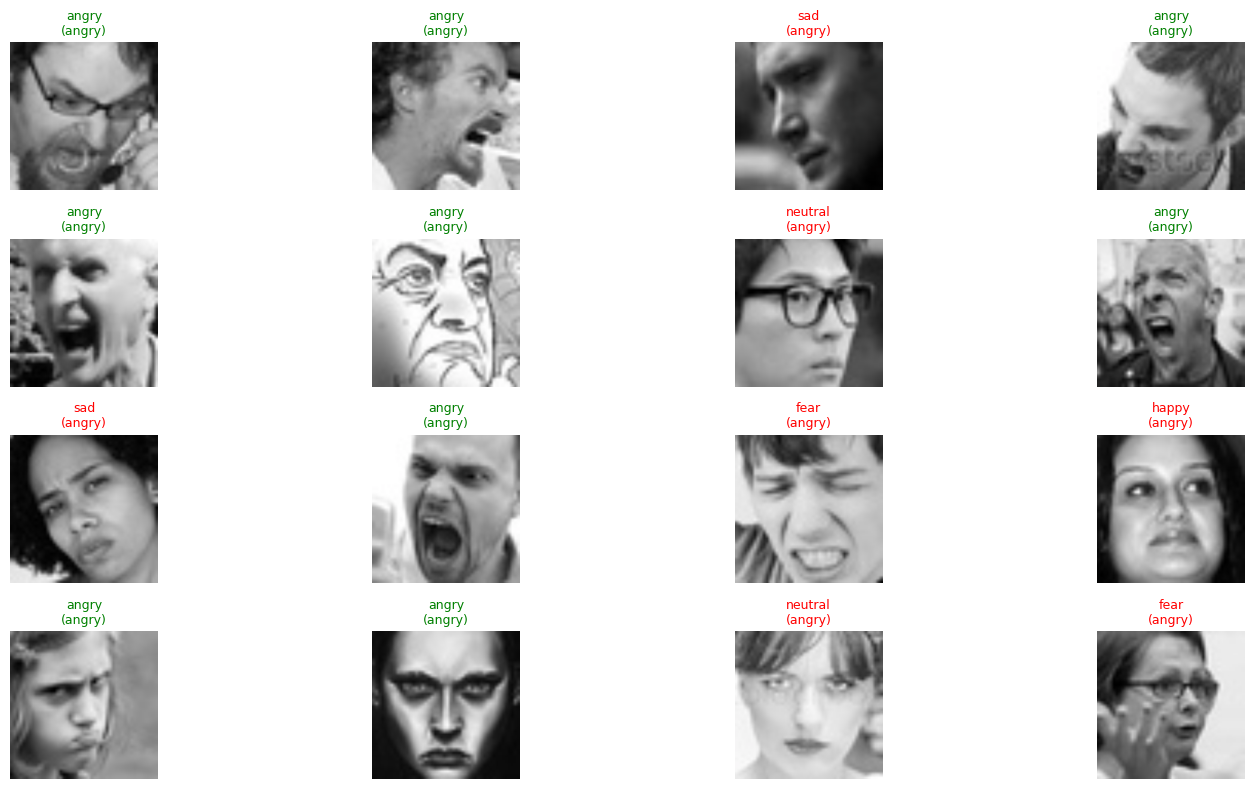

In [26]:
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    logits = model(images)
    probs = torch.softmax(logits, dim=1)
    preds = logits.argmax(dim=1)

# Normalisierung rückgängig machen für Anzeige
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

plt.figure(figsize=(16, 8))
for i in range(min(16, len(images))):
    plt.subplot(4, 4, i + 1)
    img = images[i].cpu() * std + mean
    img = img.permute(1, 2, 0).numpy().clip(0, 1)
    plt.imshow(img, cmap="gray")
    color = "green" if preds[i] == labels[i] else "red"
    plt.title(f"{EMOTIONEN[preds[i]]}\n({EMOTIONEN[labels[i]]})", color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()